# imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import LSTM

import warnings
warnings.filterwarnings('ignore')

2026-04-26 17:37:19.041433: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777225039.443638      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777225039.568458      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777225040.625370      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777225040.625409      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777225040.625412      55 computation_placer.cc:177] computation placer alr

# load dataset

In [2]:
df = pd.read_csv('/kaggle/input/datasets/rohulaminlabid/iotid20-dataset/IoT Network Intrusion Dataset.csv')

print("Original shape:", df.shape)
print(df['Sub_Cat'].value_counts())

# Keep only MITM ARP Spoofing and Normal traffic
df = df[df['Sub_Cat'].isin(['MITM ARP Spoofing', 'Normal'])]
print("\nFiltered shape:", df.shape)
print(df['Sub_Cat'].value_counts())

Original shape: (625783, 86)
Sub_Cat
Mirai-UDP Flooding       183554
Mirai-Hostbruteforceg    121181
DoS-Synflooding           59391
Mirai-HTTP Flooding       55818
Mirai-Ackflooding         55124
Scan Port OS              53073
Normal                    40073
MITM ARP Spoofing         35377
Scan Hostport             22192
Name: count, dtype: int64

Filtered shape: (75450, 86)
Sub_Cat
Normal               40073
MITM ARP Spoofing    35377
Name: count, dtype: int64


# preprocessing

In [3]:
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

drop_cols = ['Flow ID', 'Src IP', 'Dst IP', 'Timestamp']
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

target_col = 'Sub_Cat'
le = LabelEncoder()
df[target_col] = le.fit_transform(df[target_col])
print("Classes:", le.classes_)  # 0 = MITM ARP Spoofing, 1 = Normal

Classes: ['MITM ARP Spoofing' 'Normal']


# Features engineering

In [4]:
X = df.drop(columns=['Label', 'Cat', 'Sub_Cat'], errors='ignore')
y = df[target_col]

non_numeric = X.select_dtypes(exclude=['number']).columns.tolist()
print("Dropping non-numeric columns:", non_numeric)
X.drop(columns=non_numeric, inplace=True)

sel = VarianceThreshold(threshold=0.01)
X = pd.DataFrame(sel.fit_transform(X), columns=X.columns[sel.get_support()])
print("Features after selection:", X.shape[1])

# Scale features (important for RNN)
scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print("MITM ARP Spoofing:", (y == 0).sum(), "| Normal:", (y == 1).sum())

Dropping non-numeric columns: ['Flow_ID', 'Src_IP', 'Dst_IP']
Features after selection: 58
MITM ARP Spoofing: 25862 | Normal: 38598


# Split

In [5]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# RNN expects shape (samples, timesteps, features) — treat each feature as a timestep
X_train = X_train.values.reshape(X_train.shape[0], X_train.shape[1], 1)
X_val   = X_val.values.reshape(X_val.shape[0], X_val.shape[1], 1)
X_test  = X_test.values.reshape(X_test.shape[0], X_test.shape[1], 1)

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")

Train: (45122, 58, 1) | Val: (9669, 58, 1) | Test: (9669, 58, 1)


# RNN Training

In [10]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    Dropout(0.3),
    LSTM(32),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=512,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.7675 - loss: 0.5019 - val_accuracy: 0.9361 - val_loss: 0.2104
Epoch 2/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9340 - loss: 0.1983 - val_accuracy: 0.9481 - val_loss: 0.1618
Epoch 3/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9501 - loss: 0.1590 - val_accuracy: 0.9544 - val_loss: 0.1428
Epoch 4/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9554 - loss: 0.1381 - val_accuracy: 0.9437 - val_loss: 0.1524
Epoch 5/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9582 - loss: 0.1238 - val_accuracy: 0.9627 - val_loss: 0.1109
Epoch 6/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9657 - loss: 0.1089 - val_accuracy: 0.9669 - val_loss: 0.1035
Epoch 7/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9682 - loss: 0.1043 - val_accuracy: 0.9707 - val_loss: 0.1005
Epoch 8/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9686 - loss: 0.1027 - val_accuracy: 0.

In [11]:
import joblib, os

os.makedirs('/kaggle/working/models', exist_ok=True)

model.save('/kaggle/working/models/lstm_model.keras')
joblib.dump(scaler, '/kaggle/working/models/scaler.pkl')
joblib.dump(le,     '/kaggle/working/models/le.pkl')
joblib.dump(sel,    '/kaggle/working/models/variance_selector.pkl')

print("Done. Go to Output tab to download.")

Done. Go to Output tab to download.


# Plot 

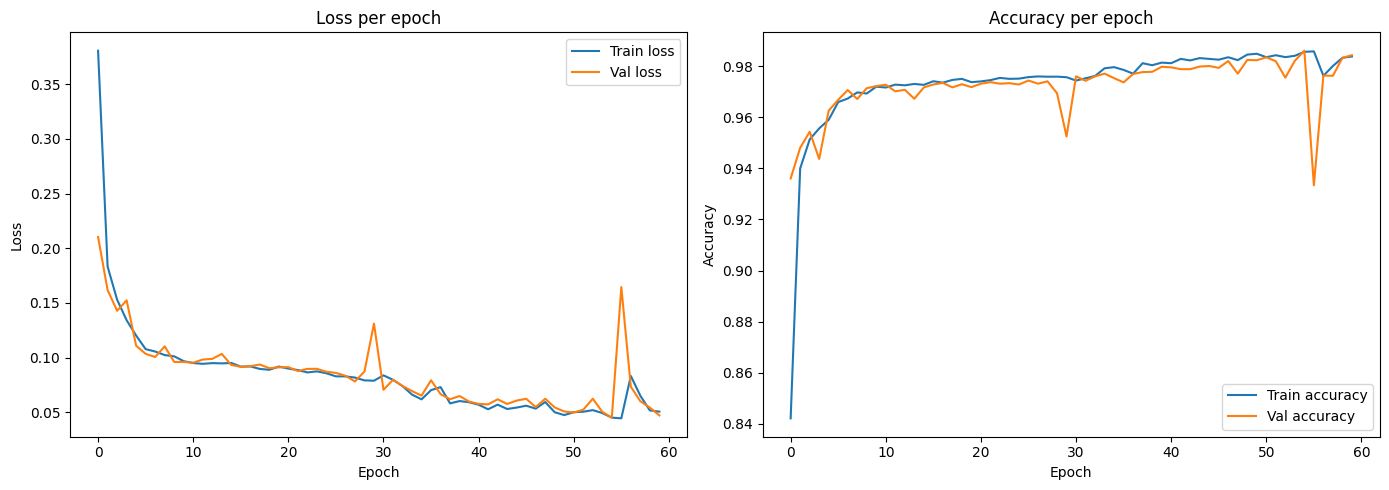

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['loss'], label='Train loss')
ax1.plot(history.history['val_loss'], label='Val loss')
ax1.set_title('Loss per epoch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(history.history['accuracy'], label='Train accuracy')
ax2.plot(history.history['val_accuracy'], label='Val accuracy')
ax2.set_title('Accuracy per epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()

# evaluation

303/303 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
                   precision    recall  f1-score   support

MITM ARP Spoofing       0.97      0.99      0.98      3880
           Normal       1.00      0.98      0.99      5789

         accuracy                           0.99      9669
        macro avg       0.98      0.99      0.98      9669
     weighted avg       0.99      0.99      0.99      9669



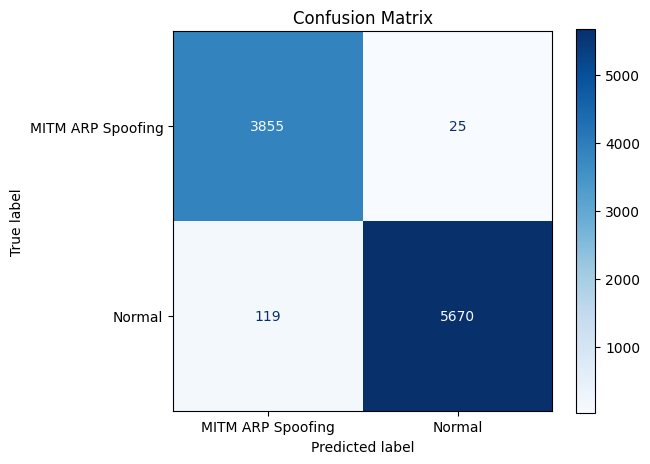

In [13]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob >= 0.5).astype(int).flatten()

print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()